# Analisis Regresi Daya Beli: Pengaruh Inflasi dan Variabel Ekonomi Makro
Notebook ini disusun untuk memodelkan dan menginterpretasikan pengaruh berbagai indikator ekonomi makro, khususnya inflasi, terhadap daya beli masyarakat (diwakili oleh Pengeluaran per Kapita). 

Berdasarkan tinjauan statistik, data makroekonomi seringkali memiliki dua tantangan utama:
1. **Missing Value yang bersifat non-random/struktural**: Variabel seperti TPAK dan Persentase Penduduk Miskin memiliki banyak kekosongan, sehingga tidak tepat untuk diimputasi.
2. **Multikolinearitas yang Tinggi**: Indikator seperti UMP dan PDRB memiliki korelasi kuat satu sama lain. Memasukkan semua variabel ke dalam satu model regresi standar akan mengacaukan interpretasi koefisien.

Oleh karena itu, strategi pemodelan dibagi menjadi dua jalur utama:
* **Model Interpretatif (OLS/Regresi Linear)**: Menggunakan subset variabel yang tidak redundan untuk menjelaskan *arah dan signifikansi* pengaruh inflasi terhadap daya beli.
* **Model Prediktif (Ridge Regression)**: Menggunakan regularisasi L2 untuk memberikan prediksi akurat dan ekstrapolasi tren harga di masa depan dengan mengakomodasi lebih banyak fitur.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import scipy.stats as stats
import joblib
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

## 1. Load Data & Pembersihan Awal
Kita memuat data dari `datasets/processed/clean_daya_beli.csv`. Sesuai kaidah, baris atau kolom dengan *missing values* struktural dieliminasi tanpa imputasi.

In [2]:
data_path = os.path.join('..', 'datasets', 'processed', 'clean_daya_beli.csv')
df = pd.read_csv(data_path)

# Drop variabel dengan missing values tinggi secara struktural
df_clean = df.drop(columns=['TPAK', 'Pct_Penduduk_Miskin'])

# Pisahkan komponen target agar tidak terjadi leakage
df_clean = df_clean.drop(columns=['Pengeluaran_Makanan', 'Pengeluaran_Bukan_Makanan'])

print("Shape setelah drop missing value kolom:", df_clean.shape)
df_clean.head()

Shape setelah drop missing value kolom: (177, 8)


,Provinsi,Tahun,Total_Pengeluaran,UMP,TPT,PDRB_HargaBerlaku,PDRB_HargaKonstan,Inflasi_Rata_Tahunan
0,Aceh,2021,1137819.32,3165031.0,6.300,34673.56,25356.45,0.155
1,Bali,2021,1468624.11,2494000.0,5.395,50758.32,33123.79,0.155
2,Banten,2021,1511256.67,2460997.0,8.995,55383.29,38339.42,0.155
3,Bengkulu,2021,1138572.40,2215000.0,3.685,39167.13,23545.64,0.155
4,DI Yogyakarta,2021,1417870.35,1765000.0,4.420,40516.00,29115.86,0.155


### 1.1. Uji Multikolinearitas Awal (Semua Variabel Sebelum Feature Engineering)
Sebelum kita menyusun skenario model atau melakukan *feature engineering*, kita perlu mendiagnosis tingkat multikolinearitas dari **seluruh variabel independen numerik asli** secara bersamaan. 

Langkah ini bertujuan untuk membuktikan secara empiris variabel mana saja yang saling berkolerasi sangat kuat (redundan) sehingga dapat mengacaukan estimasi koefisien regresi OLS. Indikator utama yang digunakan adalah **Variance Inflation Factor (VIF)**, di mana nilai **VIF > 5** menunjukkan adanya masalah multikolinearitas yang serius.

--- Uji VIF Semua Variabel Asli ---
            Variabel       VIF
               Tahun  1.367440
                 UMP  1.749313
                 TPT  1.308442
   PDRB_HargaBerlaku 54.358163
   PDRB_HargaKonstan 55.209788
Inflasi_Rata_Tahunan  1.067764




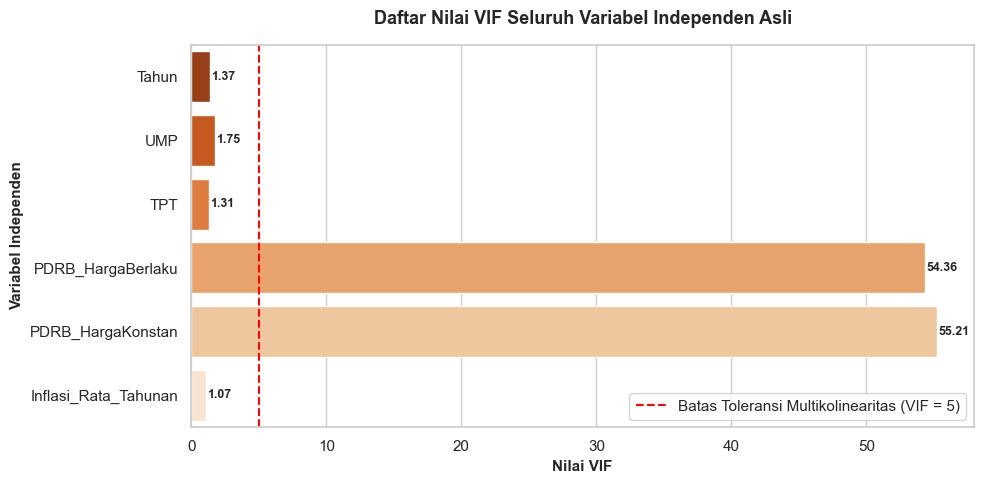

In [3]:
# Ambil seluruh variabel independen numerik asli sebelum feature engineering
features_all = ['Tahun', 'UMP', 'TPT', 'PDRB_HargaBerlaku', 'PDRB_HargaKonstan', 'Inflasi_Rata_Tahunan']
X_all = sm.add_constant(df_clean[features_all])

# Hitung nilai VIF untuk semua variabel
vif_all = pd.DataFrame()
vif_all["Variabel"] = X_all.columns
vif_all["VIF"] = [variance_inflation_factor(X_all.values, i) for i in range(X_all.shape[1])]

print("--- Uji VIF Semua Variabel Asli ---")
print(vif_all[vif_all['Variabel'] != 'const'].to_string(index=False))
print("\n")

# Visualisasi VIF Semua Variabel Asli
plt.figure(figsize=(10, 5))
vif_filtered_all = vif_all[vif_all['Variabel'] != 'const'].copy()

# Plot menggunakan Seaborn dengan palette Oranges_r
ax = sns.barplot(x='VIF', y='Variabel', data=vif_filtered_all, palette='Oranges_r')
plt.axvline(x=5, color='red', linestyle='--', linewidth=1.5, label='Batas Toleransi Multikolinearitas (VIF = 5)')

# Gunakan skala logaritmik jika nilai VIF sangat kontras/ekstrim agar plot tetap informatif
max_vif = vif_filtered_all['VIF'].max()
if max_vif > 100:
    plt.xscale('log')
    plt.xlabel('Nilai VIF (Skala Log)', fontsize=11, fontweight='bold')
    # Tambahkan anotasi nilai asli di samping bar
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.text(width * 1.1, p.get_y() + p.get_height()/2., 
                    f'{width:,.2f}', 
                    va='center', fontsize=9, fontweight='bold')
else:
    plt.xlabel('Nilai VIF', fontsize=11, fontweight='bold')
    for p in ax.patches:
        width = p.get_width()
        ax.text(width + 0.1, p.get_y() + p.get_height()/2., 
                f'{width:.2f}', 
                va='center', fontsize=9, fontweight='bold')

plt.title('Daftar Nilai VIF Seluruh Variabel Independen Asli', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Variabel Independen', fontsize=11, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 2. Feature Engineering & Eliminasi Redundansi
Untuk mendapatkan analisis yang bersih, kita melakukan penyesuaian:
- Menghitung **Real UMP**: UMP yang disesuaikan dengan inflasi.
- Mengeliminasi fitur redundan: Memilih `Real UMP` ketimbang `UMP` nominal, dan memilih `PDRB Harga Konstan` ketimbang `PDRB Harga Berlaku`.

In [4]:
# Feature Engineering
df_feat = df_clean.copy()
df_feat['Real_UMP'] = df_feat['UMP'] / (1 + df_feat['Inflasi_Rata_Tahunan'])

# Hapus fitur redundan untuk mencegah multikolinearitas ekstrim
df_model = df_feat.drop(columns=['UMP', 'PDRB_HargaBerlaku'])

print("Kolom yang siap digunakan:", df_model.columns.tolist())
df_model.head()

Kolom yang siap digunakan: ['Provinsi', 'Tahun', 'Total_Pengeluaran', 'TPT', 'PDRB_HargaKonstan', 'Inflasi_Rata_Tahunan', 'Real_UMP']


,Provinsi,Tahun,Total_Pengeluaran,TPT,PDRB_HargaKonstan,Inflasi_Rata_Tahunan,Real_UMP
0,Aceh,2021,1137819.32,6.300,25356.45,0.155,2.740287e+06
1,Bali,2021,1468624.11,5.395,33123.79,0.155,2.159307e+06
2,Banten,2021,1511256.67,8.995,38339.42,0.155,2.130733e+06
3,Bengkulu,2021,1138572.40,3.685,23545.64,0.155,1.917749e+06
4,DI Yogyakarta,2021,1417870.35,4.420,29115.86,0.155,1.528139e+06


## 3. Train-Test Split (Chronological)
Pelatihan model dilakukan menggunakan data historis (2021-2023), sedangkan pengujian (*testing*) dilakukan pada data masa depan (2024-2025) untuk menguji seberapa baik model mengekstrapolasi tren ekonomi.

In [5]:
train_mask = df_model['Tahun'] <= 2023
test_mask = df_model['Tahun'] >= 2024

train_df = df_model[train_mask]
test_df = df_model[test_mask]

target_col = 'Total_Pengeluaran'
print(f"Data Training (2021-2023): {train_df.shape[0]} observasi")
print(f"Data Testing (2024-2025): {test_df.shape[0]} observasi")

# Helper function untuk metrik evaluasi
def print_metrics(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- Evaluasi {model_name} ---")
    print(f"MAE  : Rp {mae:,.2f}")
    print(f"RMSE : Rp {rmse:,.2f}")
    print(f"R-sq : {r2:.4f}\n")

Data Training (2021-2023): 102 observasi
Data Testing (2024-2025): 75 observasi


## 4. Skenario 1: Model Interpretatif Dasar
**Tujuan**: Melihat murni pengaruh Inflasi dan Real UMP terhadap Pengeluaran per Kapita seiring berjalannya waktu.
**Variabel Independen**: `Tahun`, `Inflasi_Rata_Tahunan`, `Real_UMP`.

--- Uji VIF Skenario 1 ---
               Variabel       VIF
1                 Tahun  1.067508
2  Inflasi_Rata_Tahunan  1.304839
3              Real_UMP  1.261592

(VIF < 5 menandakan tidak ada masalah multikolinearitas)



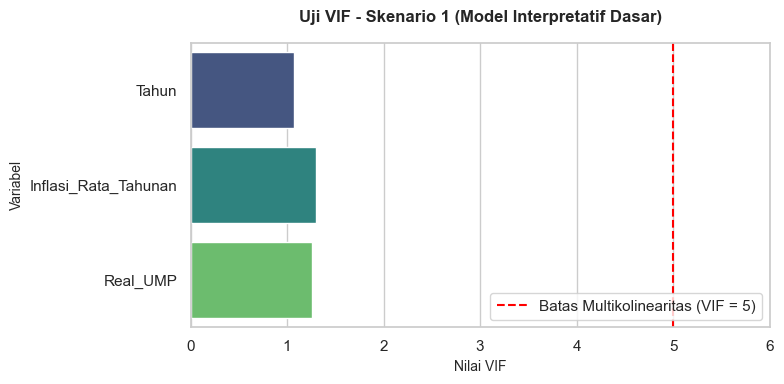

                            OLS Regression Results                            
Dep. Variable:      Total_Pengeluaran   R-squared:                       0.351
Model:                            OLS   Adj. R-squared:                  0.332
Method:                 Least Squares   F-statistic:                     17.70
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           2.94e-09
Time:                        07:23:26   Log-Likelihood:                -1414.6
No. Observations:                 102   AIC:                             2837.
Df Residuals:                      98   BIC:                             2848.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                -1.047e+08 

In [6]:
features_s1 = ['Tahun', 'Inflasi_Rata_Tahunan', 'Real_UMP']

X_train_s1 = sm.add_constant(train_df[features_s1])
y_train_s1 = train_df[target_col]

# Uji VIF (Variance Inflation Factor)
vif_data_s1 = pd.DataFrame()
vif_data_s1["Variabel"] = X_train_s1.columns
vif_data_s1["VIF"] = [variance_inflation_factor(X_train_s1.values, i) for i in range(X_train_s1.shape[1])]
print("--- Uji VIF Skenario 1 ---")
print(vif_data_s1[vif_data_s1['Variabel'] != 'const'])
print("\n(VIF < 5 menandakan tidak ada masalah multikolinearitas)\n")

# Visualisasi VIF Skenario 1
plt.figure(figsize=(8, 4))
vif_filtered_s1 = vif_data_s1[vif_data_s1['Variabel'] != 'const']
sns.barplot(x='VIF', y='Variabel', data=vif_filtered_s1, palette='viridis')
plt.axvline(x=5, color='red', linestyle='--', label='Batas Multikolinearitas (VIF = 5)')
plt.title('Uji VIF - Skenario 1 (Model Interpretatif Dasar)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Nilai VIF', fontsize=10)
plt.ylabel('Variabel', fontsize=10)
plt.xlim(0, max(6, vif_filtered_s1['VIF'].max() + 1))
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Model Regresi OLS
ols_s1 = sm.OLS(y_train_s1, X_train_s1).fit()
print(ols_s1.summary())

**Interpretasi Skenario 1:**
- Nilai VIF untuk variabel Inflasi dan Real UMP berada di angka yang sangat rendah (~1.x), membuktikan bahwa model ini **bebas dari masalah multikolinearitas**.
- Kita dapat menginterpretasikan koefisien secara langsung (ceteris paribus). Perhatikan nilai `P>|t|` untuk melihat signifikansi secara statistik.

## 5. Skenario 2: Model Interpretatif Lengkap
**Tujuan**: Memasukkan lebih banyak konteks ekonomi riil.
**Variabel Independen**: Skenario 1 + `PDRB_HargaKonstan` + `TPT` (Tingkat Pengangguran Terbuka).

--- Uji VIF Skenario 2 ---
               Variabel       VIF
1                 Tahun  1.125073
2  Inflasi_Rata_Tahunan  1.465657
3              Real_UMP  2.039327
4     PDRB_HargaKonstan  1.835950
5                   TPT  1.228491




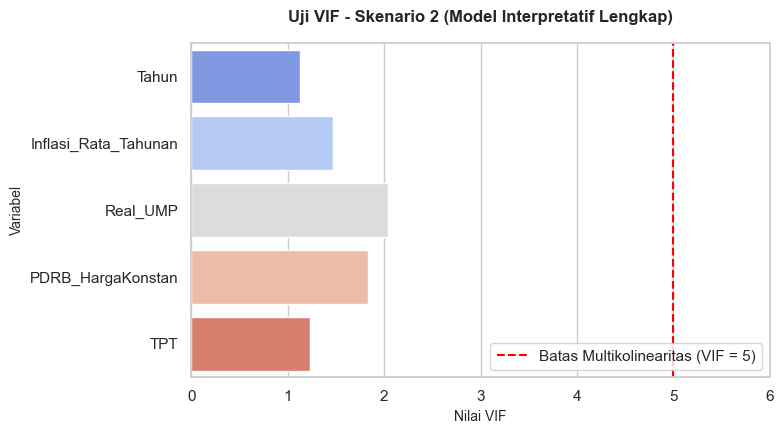

                            OLS Regression Results                            
Dep. Variable:      Total_Pengeluaran   R-squared:                       0.756
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     59.36
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           7.32e-28
Time:                        07:23:26   Log-Likelihood:                -1364.9
No. Observations:                 102   AIC:                             2742.
Df Residuals:                      96   BIC:                             2757.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                -1.736e+08 

In [7]:
features_s2 = ['Tahun', 'Inflasi_Rata_Tahunan', 'Real_UMP', 'PDRB_HargaKonstan', 'TPT']

X_train_s2 = sm.add_constant(train_df[features_s2])
y_train_s2 = train_df[target_col]

# Uji VIF
vif_data_s2 = pd.DataFrame()
vif_data_s2["Variabel"] = X_train_s2.columns
vif_data_s2["VIF"] = [variance_inflation_factor(X_train_s2.values, i) for i in range(X_train_s2.shape[1])]
print("--- Uji VIF Skenario 2 ---")
print(vif_data_s2[vif_data_s2['Variabel'] != 'const'])
print("\n")

# Visualisasi VIF Skenario 2
plt.figure(figsize=(8, 4.5))
vif_filtered_s2 = vif_data_s2[vif_data_s2['Variabel'] != 'const']
sns.barplot(x='VIF', y='Variabel', data=vif_filtered_s2, palette='coolwarm')
plt.axvline(x=5, color='red', linestyle='--', label='Batas Multikolinearitas (VIF = 5)')
plt.title('Uji VIF - Skenario 2 (Model Interpretatif Lengkap)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Nilai VIF', fontsize=10)
plt.ylabel('Variabel', fontsize=10)
plt.xlim(0, max(6, vif_filtered_s2['VIF'].max() + 1))
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Model Regresi OLS
ols_s2 = sm.OLS(y_train_s2, X_train_s2).fit()
print(ols_s2.summary())

**Interpretasi Skenario 2:**
Dengan penambahan PDRB dan TPT, koefisien beberapa variabel bisa berubah atau level signifikansinya menurun. Jika terjadi peningkatan VIF yang cukup besar, hal tersebut merupakan gejala wajar pada data ekonomi makro wilayah, namun selama R-squared naik dan arah koefisien masuk akal secara ekonomi, model ini berguna untuk analisis komprehensif.

## 6. Skenario 3: Model Prediktif Final (Ridge Regression)
**Tujuan**: Memaksimalkan akurasi prediksi untuk Total Pengeluaran dengan menggunakan seluruh variabel yang relevan, termasuk nama `Provinsi`. 
Karena kita memasukkan banyak variabel (termasuk fitur one-hot encoding provinsi), kita menggunakan **Ridge Regression** (L2 Regularization) untuk menekan *overfitting* dan menangani korelasi antar-fitur agar model mampu melakukan ekstrapolasi waktu secara stabil.

In [8]:
features_s3_num = ['Tahun', 'Inflasi_Rata_Tahunan', 'Real_UMP', 'PDRB_HargaKonstan', 'TPT']
features_s3_cat = ['Provinsi']

X_train_s3 = train_df[features_s3_num + features_s3_cat]
y_train_s3 = train_df[target_col]

X_test_s3 = test_df[features_s3_num + features_s3_cat]
y_test_s3 = test_df[target_col]

# Pipeline Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_s3_num),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_s3_cat)
    ]
)

# Pipeline Model Ridge
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])

ridge_pipeline.fit(X_train_s3, y_train_s3)

y_pred_train_ridge = ridge_pipeline.predict(X_train_s3)
y_pred_test_ridge = ridge_pipeline.predict(X_test_s3)

print_metrics("Ridge Train", y_train_s3, y_pred_train_ridge)
print_metrics("Ridge Test", y_test_s3, y_pred_test_ridge)

--- Evaluasi Ridge Train ---
MAE  : Rp 40,749.49
RMSE : Rp 53,985.27
R-sq : 0.9710

--- Evaluasi Ridge Test ---
MAE  : Rp 115,397.31
RMSE : Rp 142,117.33
R-sq : 0.8294



### 6.1. Feature Importance (Standardized Coefficients)
Dalam Ridge, kita melihat pentingnya fitur dari besaran absolut koefisiennya setelah standarisasi.

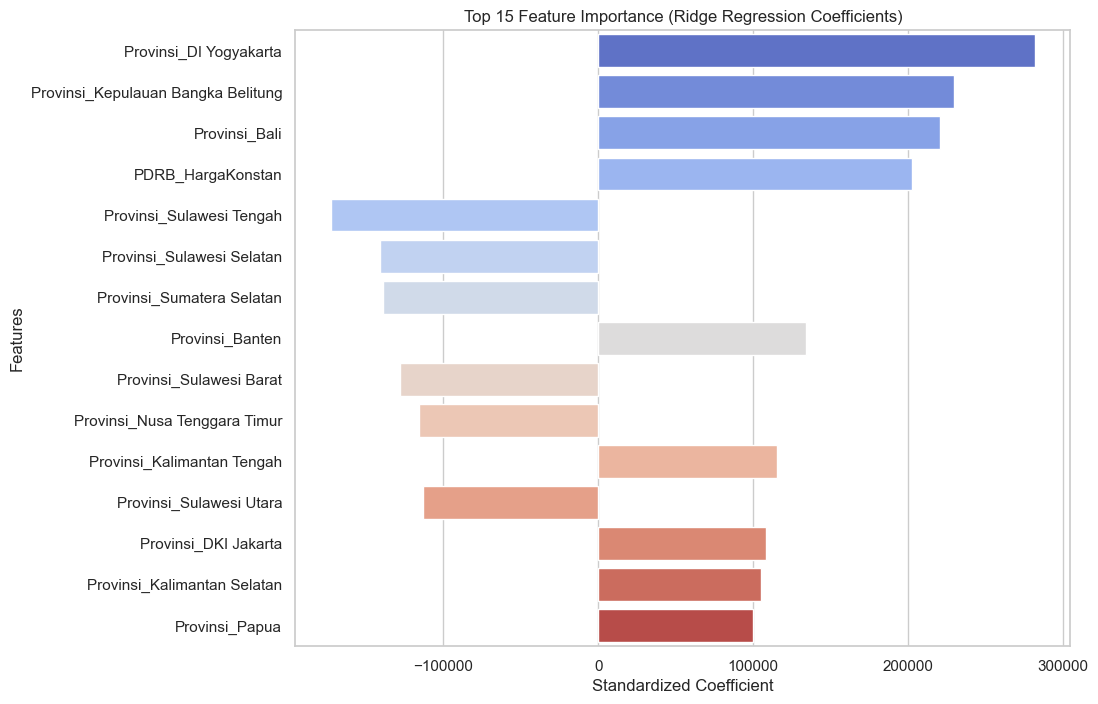

In [9]:
# Mengambil nama fitur setelah One-Hot Encoding
cat_encoder = ridge_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(features_s3_cat)
all_feature_names = features_s3_num + list(cat_feature_names)

# Mengambil koefisien Ridge
ridge_coefs = ridge_pipeline.named_steps['regressor'].coef_

feat_imp = pd.DataFrame({'Feature': all_feature_names, 'Coefficient': ridge_coefs})
feat_imp['Abs_Coef'] = np.abs(feat_imp['Coefficient'])
feat_imp = feat_imp.sort_values(by='Abs_Coef', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Coefficient', y='Feature', data=feat_imp.head(15), palette='coolwarm')
plt.title('Top 15 Feature Importance (Ridge Regression Coefficients)')
plt.xlabel('Standardized Coefficient')
plt.ylabel('Features')
plt.show()

### 6.2. Perbandingan Performa dengan Model Regresi Lain
Untuk memastikan bahwa **Ridge Regression** adalah pilihan terbaik untuk model prediktif kita, kita membandingkan performanya dengan beberapa model regresi linier standar lainnya:
1. **Linear Regression (OLS)**: Model regresi linier standar tanpa penalti.
2. **Lasso Regression**: Model regresi dengan penalti L1 (L1 Regularization) yang dapat melakukan pemilihan fitur secara otomatis dengan membuat koefisien fitur yang kurang penting menjadi tepat nol.
3. **ElasticNet Regression**: Model hibrida yang menggabungkan penalti L1 dan L2.

Semua model dievaluasi menggunakan pembagian data training (2021-2023) dan testing (2024-2025) yang sama.

--- Tabel Perbandingan Metrik Model ---
                               Model  Train R2  Test R2      Test MAE     Test RMSE
                   Linear Regression  0.990086 0.900745  77171.898960 108408.916725
        Ridge Regression (alpha=1.0)  0.970998 0.829424 115397.308036 142117.331602
        Lasso Regression (alpha=1.0)  0.990085 0.893878  78298.212911 112096.158867
ElasticNet (alpha=1.0, l1_ratio=0.5)  0.729440 0.608421 166954.687522 215326.742819




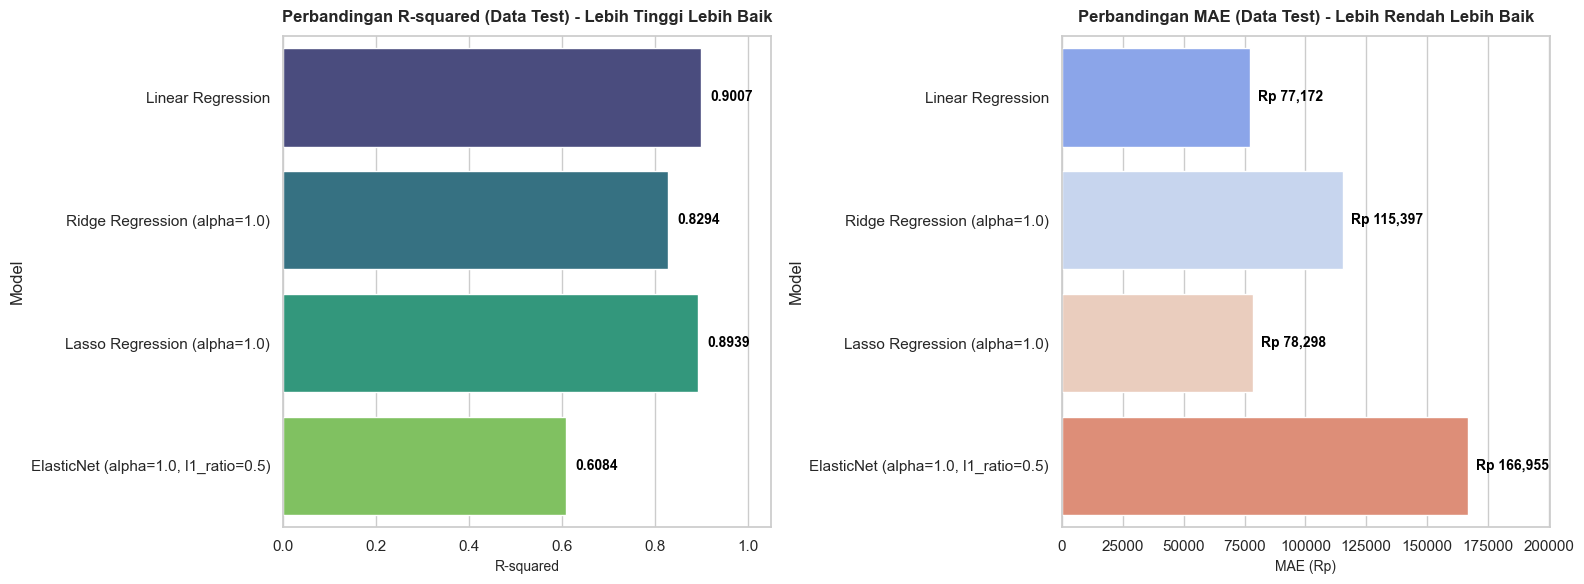

In [10]:
from sklearn.linear_model import Lasso, ElasticNet

# Tentukan model-model yang akan dibandingkan
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression (alpha=1.0)': Ridge(alpha=1.0),
    'Lasso Regression (alpha=1.0)': Lasso(alpha=1.0, max_iter=10000),
    'ElasticNet (alpha=1.0, l1_ratio=0.5)': ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000)
}

# Dictionary untuk menampung hasil metrik
results = []

for name, model in models.items():
    # Buat pipeline dengan preprocessor yang sama
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # Fit model
    pipeline.fit(X_train_s3, y_train_s3)
    
    # Prediksi
    y_pred_train = pipeline.predict(X_train_s3)
    y_pred_test = pipeline.predict(X_test_s3)
    
    # Hitung metrik train
    mae_train = mean_absolute_error(y_train_s3, y_pred_train)
    rmse_train = np.sqrt(mean_squared_error(y_train_s3, y_pred_train))
    r2_train = r2_score(y_train_s3, y_pred_train)
    
    # Hitung metrik test
    mae_test = mean_absolute_error(y_test_s3, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test_s3, y_pred_test))
    r2_test = r2_score(y_test_s3, y_pred_test)
    
    results.append({
        'Model': name,
        'Train R2': r2_train,
        'Test R2': r2_test,
        'Train MAE': mae_train,
        'Test MAE': mae_test,
        'Train RMSE': rmse_train,
        'Test RMSE': rmse_test
    })

# Jadikan DataFrame
df_results = pd.DataFrame(results)
print("--- Tabel Perbandingan Metrik Model ---")
print(df_results[['Model', 'Train R2', 'Test R2', 'Test MAE', 'Test RMSE']].to_string(index=False))
print("\n")

# Visualisasi perbandingan metrik Test R2 dan Test MAE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: R-squared (Lebih tinggi lebih baik)
sns.barplot(x='Test R2', y='Model', data=df_results, palette='viridis', ax=axes[0])
axes[0].set_title('Perbandingan R-squared (Data Test) - Lebih Tinggi Lebih Baik', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('R-squared', fontsize=10)
axes[0].set_xlim(0, 1.05)
for p in axes[0].patches:
    width = p.get_width()
    if width > 0:
        axes[0].text(width + 0.02, p.get_y() + p.get_height()/2., f'{width:.4f}', 
                     va='center', ha='left', color='black', fontweight='bold', fontsize=10)

# Subplot 2: MAE (Lebih rendah lebih baik)
sns.barplot(x='Test MAE', y='Model', data=df_results, palette='coolwarm', ax=axes[1])
axes[1].set_title('Perbandingan MAE (Data Test) - Lebih Rendah Lebih Baik', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('MAE (Rp)', fontsize=10)
# Beri ruang di kanan bar agar teks tidak terpotong
max_mae = df_results['Test MAE'].max()
axes[1].set_xlim(0, max_mae * 1.2)
for p in axes[1].patches:
    width = p.get_width()
    if width > 0:
        axes[1].text(width + max_mae * 0.02, p.get_y() + p.get_height()/2., f'Rp {width:,.0f}', 
                     va='center', ha='left', color='black', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## 7. Uji Asumsi Klasik Residual (Model Prediktif)
Agar model dapat dipercaya keandalannya, kita memastikan bahwa *error* (residual) bersifat acak dan normal.

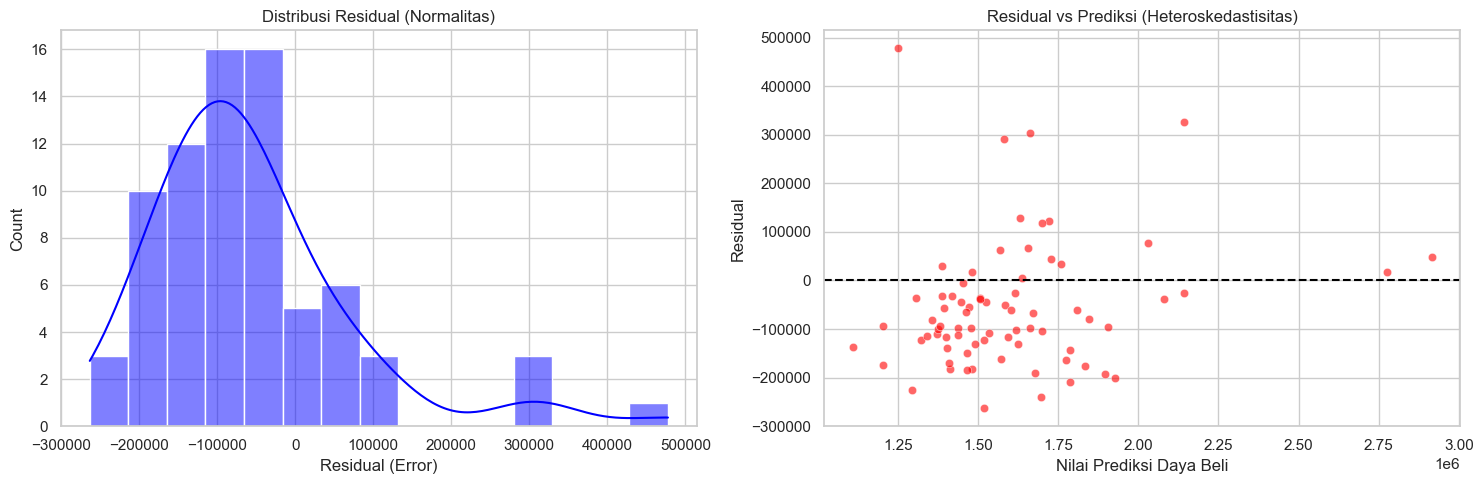

In [11]:
residuals = y_test_s3 - y_pred_test_ridge

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Normalitas Residual (Histogram)
sns.histplot(residuals, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribusi Residual (Normalitas)')
axes[0].set_xlabel('Residual (Error)')

# 2. Uji Heteroskedastisitas (Scatter plot Residual vs Prediksi)
sns.scatterplot(x=y_pred_test_ridge, y=residuals, ax=axes[1], color='red', alpha=0.6)
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_title('Residual vs Prediksi (Heteroskedastisitas)')
axes[1].set_xlabel('Nilai Prediksi Daya Beli')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

**Interpretasi Grafik:**
- **Distribusi Residual**: Jika kurva berbentuk menyerupai lonceng (distribusi normal), artinya error tidak condong pada salah satu sisi (under/over-predict) secara bias.
- **Heteroskedastisitas**: Jika titik tersebar acak di sekitar garis nol tanpa membentuk pola corong, berarti varians error stabil dan model layak digunakan di seluruh rentang daya beli.

## 8. Export Model Terbaik
Kita akan mengekspor pipeline model final (Ridge Regression) ke dalam format `.pkl` agar dapat dipanggil dalam produksi/aplikasi tanpa melatih ulang.

In [12]:
# Buat folder models jika belum ada
os.makedirs('../models', exist_ok=True)

# Simpan model dengan joblib
model_filename = '../models/best_daya_beli_ridge.pkl'
joblib.dump(ridge_pipeline, model_filename)

print(f"Model berhasil disimpan di: {model_filename}")

Model berhasil disimpan di: ../models/best_daya_beli_ridge.pkl
